In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, LSTM, Bidirectional,
    Dense, Dropout, SpatialDropout1D
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score
)

print("Tensorflow version:",tf.__version__)
print("Keras version:",tf.keras.__version__)
print("GPU Available:",tf.config.list_physical_devices('GPU'))


Tensorflow version: 2.20.0
Keras version: 3.13.2
GPU Available: []


In [2]:
pd.set_option('display.max_colwidth',None)
df = pd.read_csv('/content/clean_data.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (5635, 5)

Columns: ['Text', 'Sentiment', 'Emotion', 'text_length', 'word_count']


,Text,Sentiment,Emotion,text_length,word_count
0,"এসব পাছা কবিরের আজাইররা পোস্ট। হেতি ক, ""যদি ভুল করে থাকি!! "" কত্ত বড় হারামজাদি ইতে!! উষ্ঠা মারা উচিত হেতিরে।",Negative,Creepy,110,20
1,জুতা মারি গরুদান মারান!! আপনার আম্মা আব্বার খেলা দেখে কি সিউর হইছিলেন আপনি তাদেরই মেয়ে???,Strongly Negative,Creepy,89,15
2,"সুখে থাকতে ভুতে কিলাই, প্রবাদটা এর কাজের দ্বারা আবারো প্রমানিত। এর অভিযোগের বাস্তবতা ওরে দিয়েই বাস্তবায়ন করা হোক।",Negative,Bullying,113,18
3,তর মাথায় ব্রেন আছে সেটা তুই দেখছস? না দেখলে ভাব্বি গবর আছে,Strongly Negative,Bullying,58,12
4,আপনি কি নাস্তিক..?,Negative,Unbiased,18,3


In [3]:
print("Sentiment classes:", df['Sentiment'].unique())
print("Emotion classes:", df['Emotion'].unique())
print("\nNull values:", df.isnull().sum().sum())

Sentiment classes: ['Negative' 'Strongly Negative' 'Strongly Positive' 'Neutral' 'Positive']
Emotion classes: ['Creepy' 'Bullying' 'Unbiased' 'Joyful' 'Surprise']

Null values: 0


In [4]:
import re

#URL Detection
url_pattern = r'http\S+|www\S+'
url_count = df['Text'].str.contains(url_pattern, regex=True).sum()
print(f"Rows containing URLs: {url_count}")

#Emoji Detection
actual_emoji = re.compile(r'[\U0001F300-\U0001FFFF]')
emoji_only_count = df['Text'].apply(
    lambda x: bool(actual_emoji.search(str(x)))
).sum()
print(f"Rows containing actual emojis: {emoji_only_count}")


# Special Punctuation Detection  (excluding emojis)
punct_pattern = re.compile(
    r'[^\u0980-\u09FF\u0000-\u007F\s\U0001F300-\U0001FFFF]'
)
punct_count = df['Text'].apply(
    lambda x: bool(punct_pattern.search(str(x)))
).sum()
print(f"Rows containing special punctuation/symbols: {punct_count}")


Rows containing URLs: 18
Rows containing actual emojis: 31
Rows containing special punctuation/symbols: 2296


In [5]:
# URL Samples in data
print("\nURL Example:")
url_rows = df[df['Text'].str.contains(url_pattern, regex=True)]
if len(url_rows) > 0:
    print(url_rows['Text'].iloc[0:5])
else:
    print("No URL found")


URL Example:
146                                                                                   সবাই প্রতিবাদ করুন নিচের লিংকে গিয়ে..... https://www.facebook.com/abc4utah/videos/2301600330105127/?fref=mentions
988                                                                                 কেউ কিছু বলতে চাইলে এই লিংকে যাই কিছু বলেন https://www.facebook.com/129914100452483/posts/2008240172619857/?app=fbl
1140                                                 আসুন দর্পনের চোখে বাংলাদেশ কে দেখি। তাই আর দেরি না করে (বাংলার  দর্পণ) গ্রুপে জয়েন করি❗✅https://www.facebook.com/groups/469823917202282/?ref=share
1448                                                                                                           এধরনের একটি প্রশ্নের উত্তর দিয়েছেন আসিফ মহিউদ্দীন৷ পাবেন এই লিংকে: http://dw.com/p/1Gghk
1757    ডয়চে ভেলে বাকস্বাধীনতার পক্ষে৷ আর আমরা শুধু নাস্তিকদের মতামত নয়, সবপক্ষের মতামতই তুলে ধরার চেষ্টা করছি৷ আমাদের নতুন আয়োজন #dwAlaap সম্পর্কে বিস্তারিত জানতে ভিজিট করুন: http://www

In [6]:
# Actual Emoji Sample
print("\nActual Emoji Example:")
emoji_rows = df[df['Text'].apply(
    lambda x: bool(actual_emoji.search(str(x)))
)]
if len(emoji_rows) > 0:
    print(emoji_rows['Text'].iloc[0:5])
else:
    print("No actual emoji found")


Actual Emoji Example:
69                             খানকিদের লিস্টে তুই সবার উপর থাকবি 🖕🖕🖕🖕🖕
260                                         সত্য বলার কলিজা বহাল রাখুন👍
261     হা হা হা ইম্রান এইডসের শিশ্য রাজাকারের ছানা 😜 হা হা হা মগাই মগা
262                 সত্য বলার এই কলিজা সবসময় রাখুন সত্যের জয় অনিবার্য 👍
1010                       দুধ দেখায় কি লাভ। ঝুলে যাওয়া দুধ কে খাবে।🙄🙄🙄
Name: Text, dtype: object


In [7]:
# Special Punctuation Example
print("\nSpecial Punctuation Example:")
punct_rows = df[df['Text'].apply(
    lambda x: bool(punct_pattern.search(str(x)))
)]
if len(punct_rows) > 0:
    print(punct_rows['Text'].iloc[0:5])
else:
    print("No special punctuation found")


Special Punctuation Example:
0                         এসব পাছা কবিরের আজাইররা পোস্ট। হেতি ক, "যদি ভুল করে থাকি!! " কত্ত বড় হারামজাদি ইতে!!  উষ্ঠা মারা উচিত হেতিরে।
2                      সুখে থাকতে ভুতে কিলাই, প্রবাদটা এর কাজের দ্বারা আবারো প্রমানিত। এর অভিযোগের বাস্তবতা ওরে দিয়েই বাস্তবায়ন করা হোক।
5                                                                                                                      আলহামদুলিল্লাহ ♥♥
8     সেটা আগেই করা উচিৎ না ।আগে আমরা Imran H Sarker এর মন্তব্য শুনতে চাই ... ও হ্যাঁ , কোথায় যেন শুনেছিলাম মৌনতা সম্মতির লক্ষণ.........
12                                    অন্যায় কে অন্যায় বলা, আর সত্যকে সত্য, বলাই ভয় পাইনা ইমরান ভাই, আমরা জেগে আছি,সাথে আছি, সাথে থাকবো।
Name: Text, dtype: object


In [8]:
def clean_text(text):

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove emojis
    text = re.sub(r'[\U0001F300-\U0001FFFF]', '', text)
    text = re.sub(r'[^\u0980-\u09FF\s]', '', text)
    text = re.sub(r'[।৷]', '', text)
    # Bengali & English numbers remove
    text = re.sub(r'[০-৯\d]+', '', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['clean_text'] = df['Text'].apply(clean_text)

# Before vs After
emoji_rows = df[df['Text'].str.contains(r'[\U0001F300-\U0001FFFF]', regex=True)]
idx = emoji_rows.index[0:4]

print("BEFORE:", df['Text'].iloc[idx])
print("AFTER: ", df['clean_text'].iloc[idx])

BEFORE: 69                            খানকিদের লিস্টে তুই সবার উপর থাকবি 🖕🖕🖕🖕🖕
260                                        সত্য বলার কলিজা বহাল রাখুন👍
261    হা হা হা ইম্রান এইডসের শিশ্য রাজাকারের ছানা 😜 হা হা হা মগাই মগা
262                সত্য বলার এই কলিজা সবসময় রাখুন সত্যের জয় অনিবার্য 👍
Name: Text, dtype: object
AFTER:  69                                খানকিদের লিস্টে তুই সবার উপর থাকবি
260                                       সত্য বলার কলিজা বহাল রাখুন
261    হা হা হা ইম্রান এইডসের শিশ্য রাজাকারের ছানা হা হা হা মগাই মগা
262                সত্য বলার এই কলিজা সবসময় রাখুন সত্যের জয় অনিবার্য
Name: clean_text, dtype: object


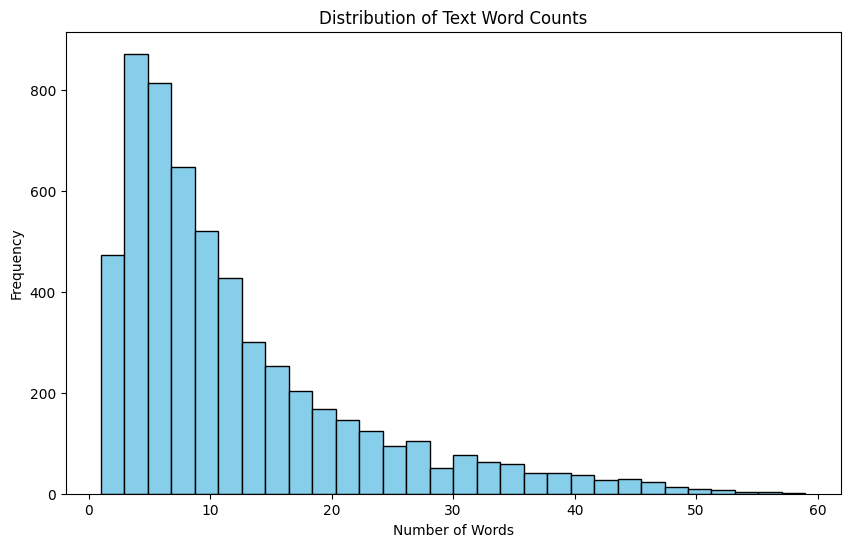

In [9]:
plt.figure(figsize=(10, 6))
plt.hist(df['word_count'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Text Word Counts')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

In [10]:
max_len = int(np.percentile(df['word_count'], 95))
print(f"95% of the data is covered within {max_len} words.")

95% of the data is covered within 34 words.


In [11]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

VOCAB_SIZE = 8000
MAX_LEN = 34
EMBEDDING_DIM = 128
OOV_TOKEN = '<OOV>'

keras_tokenizer =Tokenizer(num_words=VOCAB_SIZE,oov_token=OOV_TOKEN)
keras_tokenizer.fit_on_texts(df['clean_text'])

vocab_size_actual = len(keras_tokenizer.word_index) + 1
print(f"Actual vocabulary size : {vocab_size_actual}")
print(f"Using top             : {VOCAB_SIZE} words")

sequences = keras_tokenizer.texts_to_sequences(df['clean_text'])

# Pad sequences
X = pad_sequences(sequences, maxlen=max_len, padding='pre', truncating='post')
print(f"\nX shape: {X.shape}")
print("1st row text:", df['clean_text'].iloc[0])
print(f"Sample sequence (first row): {X[0]}")

Actual vocabulary size : 14034
Using top             : 8000 words

X shape: (5635, 34)
1st row text: এসব পাছা কবিরের আজাইররা পোস্ট হেতি ক যদি ভুল করে থাকি কত্ত বড় হারামজাদি ইতে উষ্ঠা মারা উচিত হেতিরে
Sample sequence (first row): [   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0  227  271  309 4872  257 2355 1204   58  101    4  594 1592  804
 1374 4873 4874  155   77 1593]


In [12]:
from sklearn.preprocessing import LabelEncoder

le_sentiment = LabelEncoder()
y_sentiment  = le_sentiment.fit_transform(df['Sentiment'])

le_emotion   = LabelEncoder()
y_emotion    = le_emotion.fit_transform(df['Emotion'])

print("Sentiment classes:", df['Sentiment'].iloc[0:9].tolist())
print("Sentiment classes(After):", y_sentiment[0:9])
print("Emotion classes  :", df['Emotion'].iloc[0:9].tolist())
print("Emotion classes(After):", y_emotion[0:9])

Sentiment classes: ['Negative', 'Strongly Negative', 'Negative', 'Strongly Negative', 'Negative', 'Strongly Positive', 'Negative', 'Neutral', 'Strongly Positive']
Sentiment classes(After): [0 3 0 3 0 4 0 1 4]
Emotion classes  : ['Creepy', 'Creepy', 'Bullying', 'Bullying', 'Unbiased', 'Unbiased', 'Unbiased', 'Creepy', 'Joyful']
Emotion classes(After): [1 1 0 0 4 4 4 1 2]


In [13]:
from sklearn.model_selection import train_test_split

def get_splits(X, y, random_state=42):
    # First split: 70% train, 30% temp
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.30,
        random_state=random_state, stratify=y
    )
    # Second split: 50% of temp → val, 50% → test  (15% each of total)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50,
        random_state=random_state, stratify=y_temp
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

# Sentiment splits
X_train_s, X_val_s, X_test_s, y_train_s, y_val_s, y_test_s = get_splits(X, y_sentiment)

# Emotion splits
X_train_e, X_val_e, X_test_e, y_train_e, y_val_e, y_test_e = get_splits(X, y_emotion)

print("Sentiment splits:")
print(f"  Train : {X_train_s.shape}  Val : {X_val_s.shape}  Test : {X_test_s.shape}")
print("\nEmotion splits:")
print(f"  Train : {X_train_e.shape}  Val : {X_val_e.shape}  Test : {X_test_e.shape}")

Sentiment splits:
  Train : (3944, 34)  Val : (845, 34)  Test : (846, 34)

Emotion splits:
  Train : (3944, 34)  Val : (845, 34)  Test : (846, 34)


In [14]:
def plot_history(history, title):
    """Plot training vs validation accuracy and loss."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    # Accuracy
    axes[0].plot(history.history['accuracy'],     label='Train Accuracy', lw=2)
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   lw=2)
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Loss
    axes[1].plot(history.history['loss'],     label='Train Loss', lw=2)
    axes[1].plot(history.history['val_loss'], label='Val Loss',   lw=2)
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [15]:
def plot_confusion(y_true, y_pred, class_names, title, cmap='Blues'):
    """Plot confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

In [16]:
def evaluate_model(model, X_test, y_test, class_names, label='Model'):
    """Print classification report and return F1 + accuracy."""
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    f1  = f1_score(y_test, y_pred, average='weighted')
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{'='*50}")
    print(f" {label}")
    print(f"{'='*50}")
    print(f" Test F1 (weighted) : {f1:.4f}")
    print(f" Test Accuracy      : {acc:.4f}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=class_names))
    return y_pred, f1, acc

In [17]:
# Callbacks (shared)
def get_callbacks():
    return [
        EarlyStopping(monitor='val_loss', patience=3,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=2, min_lr=1e-6, verbose=1)
    ]

In [18]:
from tensorflow.keras.optimizers import Adam

def build_lstm_model(num_classes, vocab_size=VOCAB_SIZE,
                     embedding_dim=EMBEDDING_DIM, max_len=MAX_LEN,
                     lstm_units=128):
    model = Sequential([
        Embedding(vocab_size, embedding_dim, input_length=max_len),
        SpatialDropout1D(0.2),
        LSTM(lstm_units, dropout=0.2),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ], name='LSTM_model')


    opt = Adam(learning_rate=0.001)

    model.compile(
        optimizer=opt,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [19]:
def build_bilstm_model(num_classes, vocab_size=VOCAB_SIZE,
                       embedding_dim=EMBEDDING_DIM, max_len=MAX_LEN,
                       lstm_units=128):
    model = Sequential([
        Embedding(vocab_size, embedding_dim, input_length=max_len),
        SpatialDropout1D(0.3),
        Bidirectional(LSTM(lstm_units, dropout=0.3, recurrent_dropout=0.3)),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ], name='BiLSTM_model')

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [20]:
model = build_lstm_model(5)
model.build(input_shape=(None, MAX_LEN))
model.summary()

Model: "LSTM_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 34, 128)        │     1,024,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 34, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,164,165 (4.44 MB)

 Trainable params: 1,164,165 (4.44 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
N_SENTIMENT = len(le_sentiment.classes_)

lstm_sentiment = build_lstm_model(num_classes=N_SENTIMENT)

history_lstm_s = lstm_sentiment.fit(
    X_train_s, y_train_s,
    epochs=20,
    batch_size=32,
    validation_data=(X_val_s, y_val_s),
    callbacks=get_callbacks(),
    verbose=1
)


Epoch 1/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 23s 103ms/step - accuracy: 0.3436 - loss: 1.4881 - val_accuracy: 0.4379 - val_loss: 1.2423 - learning_rate: 0.0010
Epoch 2/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 18s 149ms/step - accuracy: 0.5535 - loss: 1.0188 - val_accuracy: 0.5195 - val_loss: 1.0947 - learning_rate: 0.0010
Epoch 3/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 13s 85ms/step - accuracy: 0.7051 - loss: 0.7426 - val_accuracy: 0.5456 - val_loss: 1.1257 - learning_rate: 0.0010
Epoch 4/20
123/124 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.8213 - loss: 0.4896
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
124/124 ━━━━━━━━━━━━━━━━━━━━ 10s 79ms/step - accuracy: 0.8083 - loss: 0.5064 - val_accuracy: 0.5456 - val_loss: 1.2882 - learning_rate: 0.0010
Epoch 5/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 12s 91ms/step - accuracy: 0.8910 - loss: 0.3188 - val_accuracy: 0.5456 - val_loss: 1.4639 - learning_rate: 5.0000e-04
Epoch 5: early stopping
Restoring model weights from the end of the best

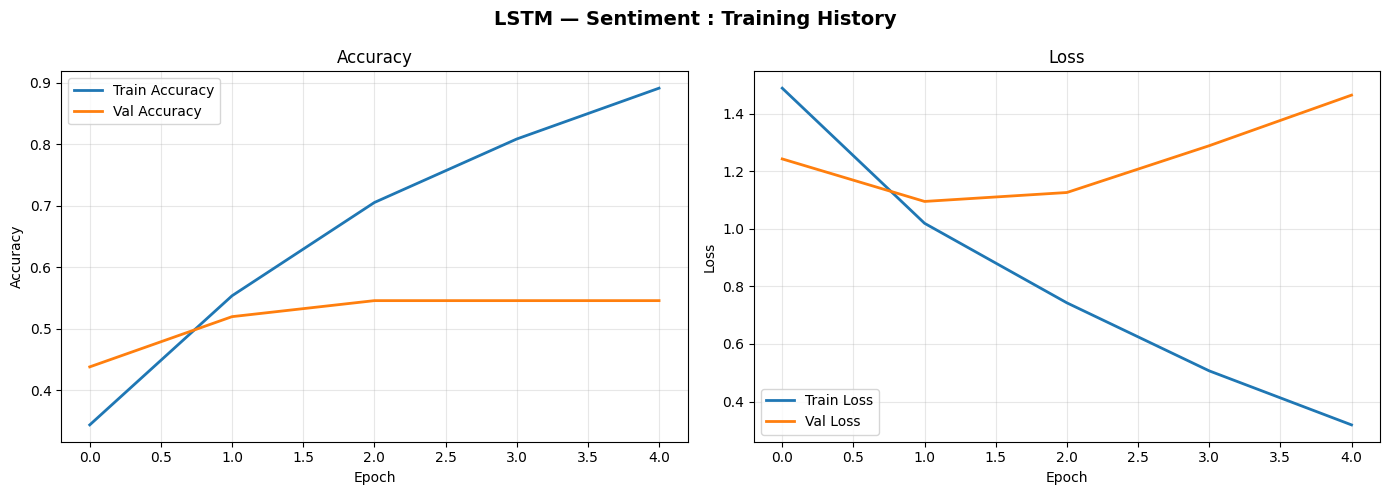

In [22]:
plot_history(history_lstm_s, 'LSTM — Sentiment : Training History')


In [23]:
y_pred_lstm_s, f1_lstm_s, acc_lstm_s = evaluate_model(
    lstm_sentiment, X_test_s, y_test_s,
    class_names=le_sentiment.classes_,
    label='LSTM — Sentiment'
)



 LSTM — Sentiment
 Test F1 (weighted) : 0.5418
 Test Accuracy      : 0.5449
                   precision    recall  f1-score   support

         Negative       0.63      0.55      0.59       197
          Neutral       0.37      0.33      0.35       147
         Positive       0.45      0.70      0.55       182
Strongly Negative       0.75      0.70      0.73       174
Strongly Positive       0.55      0.38      0.45       146

         accuracy                           0.54       846
        macro avg       0.55      0.53      0.53       846
     weighted avg       0.56      0.54      0.54       846



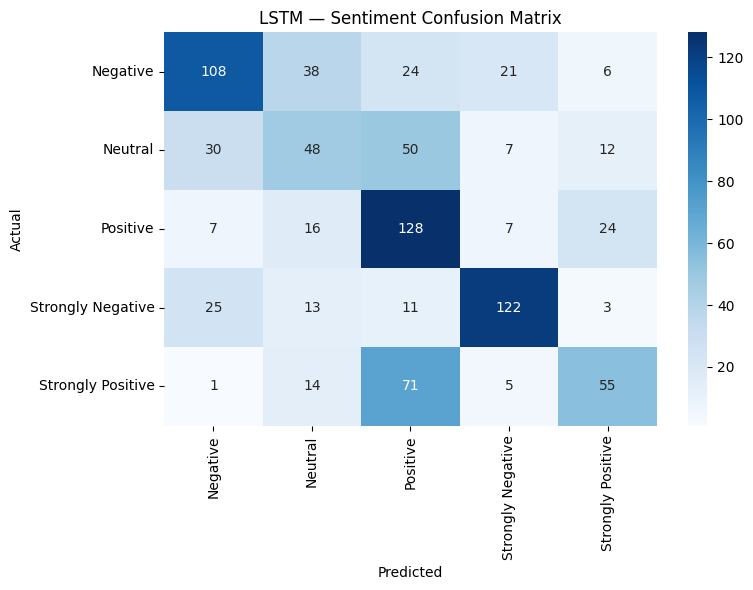

In [24]:
plot_confusion(
    y_test_s, y_pred_lstm_s,
    class_names=le_sentiment.classes_,
    title='LSTM — Sentiment Confusion Matrix'
)

In [25]:
bilstm_sentiment = build_bilstm_model(num_classes=N_SENTIMENT)

history_bilstm_s = bilstm_sentiment.fit(
    X_train_s, y_train_s,
    epochs=20,
    batch_size=32,
    validation_data=(X_val_s, y_val_s),
    callbacks=get_callbacks(),
    verbose=1
)


Epoch 1/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 48s 285ms/step - accuracy: 0.2931 - loss: 1.5323 - val_accuracy: 0.4142 - val_loss: 1.2876 - learning_rate: 0.0010
Epoch 2/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 28s 222ms/step - accuracy: 0.5099 - loss: 1.1195 - val_accuracy: 0.5089 - val_loss: 1.1309 - learning_rate: 0.0010
Epoch 3/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 28s 223ms/step - accuracy: 0.6575 - loss: 0.8474 - val_accuracy: 0.5385 - val_loss: 1.0923 - learning_rate: 0.0010
Epoch 4/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 27s 220ms/step - accuracy: 0.7546 - loss: 0.6417 - val_accuracy: 0.5444 - val_loss: 1.1674 - learning_rate: 0.0010
Epoch 5/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.8236 - loss: 0.4763
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
124/124 ━━━━━━━━━━━━━━━━━━━━ 28s 222ms/step - accuracy: 0.8187 - loss: 0.4955 - val_accuracy: 0.5479 - val_loss: 1.2642 - learning_rate: 0.0010
Epoch 6/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 41s 227ms/step - accuracy: 0.888

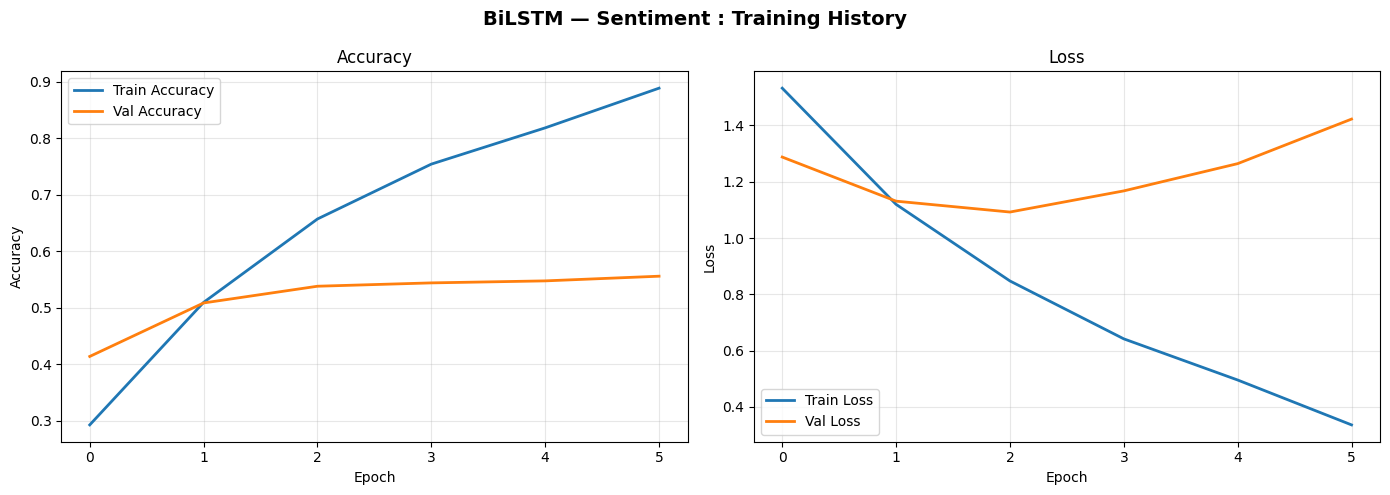

In [26]:
plot_history(history_bilstm_s, 'BiLSTM — Sentiment : Training History')

In [27]:
y_pred_bilstm_s, f1_bilstm_s, acc_bilstm_s = evaluate_model(
    bilstm_sentiment, X_test_s, y_test_s,
    class_names=le_sentiment.classes_,
    label='BiLSTM — Sentiment'
)


 BiLSTM — Sentiment
 Test F1 (weighted) : 0.5573
 Test Accuracy      : 0.5532
                   precision    recall  f1-score   support

         Negative       0.67      0.58      0.62       197
          Neutral       0.34      0.37      0.36       147
         Positive       0.56      0.51      0.54       182
Strongly Negative       0.73      0.69      0.71       174
Strongly Positive       0.46      0.59      0.52       146

         accuracy                           0.55       846
        macro avg       0.55      0.55      0.55       846
     weighted avg       0.57      0.55      0.56       846

